# Ejercicio 1.5 y Ejercicio 2 - Analisis exploratorio y variable respuesta

Parte 2 del Laboratorio 4 (Machine Learning). Este cuaderno cubre el inciso
1.5 (analisis exploratorio de las variables que se usaran para modelar) y
el ejercicio 2 completo (construccion de la variable respuesta binaria
`cyano_alta`).

Depende de `data/processed/ml/dataset_ml.parquet`, ya construido por el
ejercicio 1 (`notebooks/09_dataset_ml.ipynb`). No reabre rasters ni
recalcula indices.

## 0. Verificacion del trabajo previo (gate)

Antes de empezar se exige que el conjunto de datos del ejercicio 1 pase su
propio contrato. Si esto falla, el problema esta en el ejercicio 1, no
aqui.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src.dataset_ml import leer_dataset, verificar_dataset
from src.config import UMBRAL_CIANOBACTERIA_ALTO_UGL, VARIABLES_EXCLUIDAS_RESPUESTA, LAGOS

resumen = verificar_dataset()
print(f"Gate del ejercicio 1 correcto: {resumen['observaciones']} observaciones de "
      f"{resumen['resolucion_m']} m en {resumen['combinaciones']} combinaciones lago-fecha.")


Gate del ejercicio 1 correcto: 492677 observaciones de 50 m en 22 combinaciones lago-fecha.


## 1. Ejercicio 1.5 - Analisis exploratorio

Se exploran las cinco variables numericas del dataset (`B03`, `B08`,
`ndvi`, `ndwi`, `cianobacteria_ugl`) antes de decidir que va a modelo. No
se incluye `B04` en la interpretacion como candidata a predictora porque
ya se sabe que quedara excluida por fuga (ver seccion 5).

In [2]:
from src import eda

tabla = leer_dataset()
print(f"Filas: {len(tabla)}")
display(tabla.head())


Filas: 492677


,lago,fecha,x_utm,y_utm,lon,lat,B03,B04,B08,ndvi,ndwi,cianobacteria_ugl,n_pixeles_validos,frac_valida
0,amatitlan,2025-01-28,757645.0,1603375.0,-90.609642,14.491000,0.026318,0.019800,0.019153,-0.017530,0.158667,4.728932,17,0.68
1,amatitlan,2025-01-28,757695.0,1603375.0,-90.609178,14.490995,0.026971,0.021238,0.020192,-0.029098,0.147370,4.683918,24,0.96
2,amatitlan,2025-01-28,757745.0,1603375.0,-90.608714,14.490991,0.025148,0.020183,0.018965,-0.034603,0.142702,4.717793,23,0.92
3,amatitlan,2025-01-28,757795.0,1603375.0,-90.608251,14.490986,0.025006,0.019594,0.019106,-0.012369,0.132742,4.698077,16,0.64
4,amatitlan,2025-01-28,757595.0,1603325.0,-90.610110,14.490553,0.030995,0.022777,0.021941,-0.017740,0.170967,4.756404,22,0.88


### 1.1 Estadisticas descriptivas por lago

In [3]:
display(eda.estadisticas_descriptivas(tabla, por='lago').round(4))


B03                                                          \
              count    mean     std     min     25%     50%     75%     max   
lago                                                                          
amatitlan   60642.0  0.0478  0.0274  0.0082  0.0205  0.0506  0.0684  0.1235   
atitlan    432035.0  0.0207  0.0079  0.0059  0.0142  0.0204  0.0251  0.0979   

                B08          ...    ndwi         cianobacteria_ugl         \
              count    mean  ...     75%     max             count   mean   
lago                         ...                                            
amatitlan   60642.0  0.0255  ...  0.4963  0.9898           60642.0  6.119   
atitlan    432035.0  0.0096  ...  0.5445  1.0000          432035.0  1.454   

                                                            
              std     min     25%     50%     75%      max  
lago                                                        
amatitlan  3.9242  1.7642  4.2100  4.7506  6.0431  45.3599  
atitlan    0.7391  0.0949  0.8586  1.3332  1.9580  32.2998  

[2 rows x 40 columns]

### 1.2 Histogramas

`cianobacteria_ugl` se grafica con el eje y en escala logaritmica porque
la enorme mayoria de celdas tiene valores bajos y una cola larga de
valores altos la aplastaria en una escala lineal.

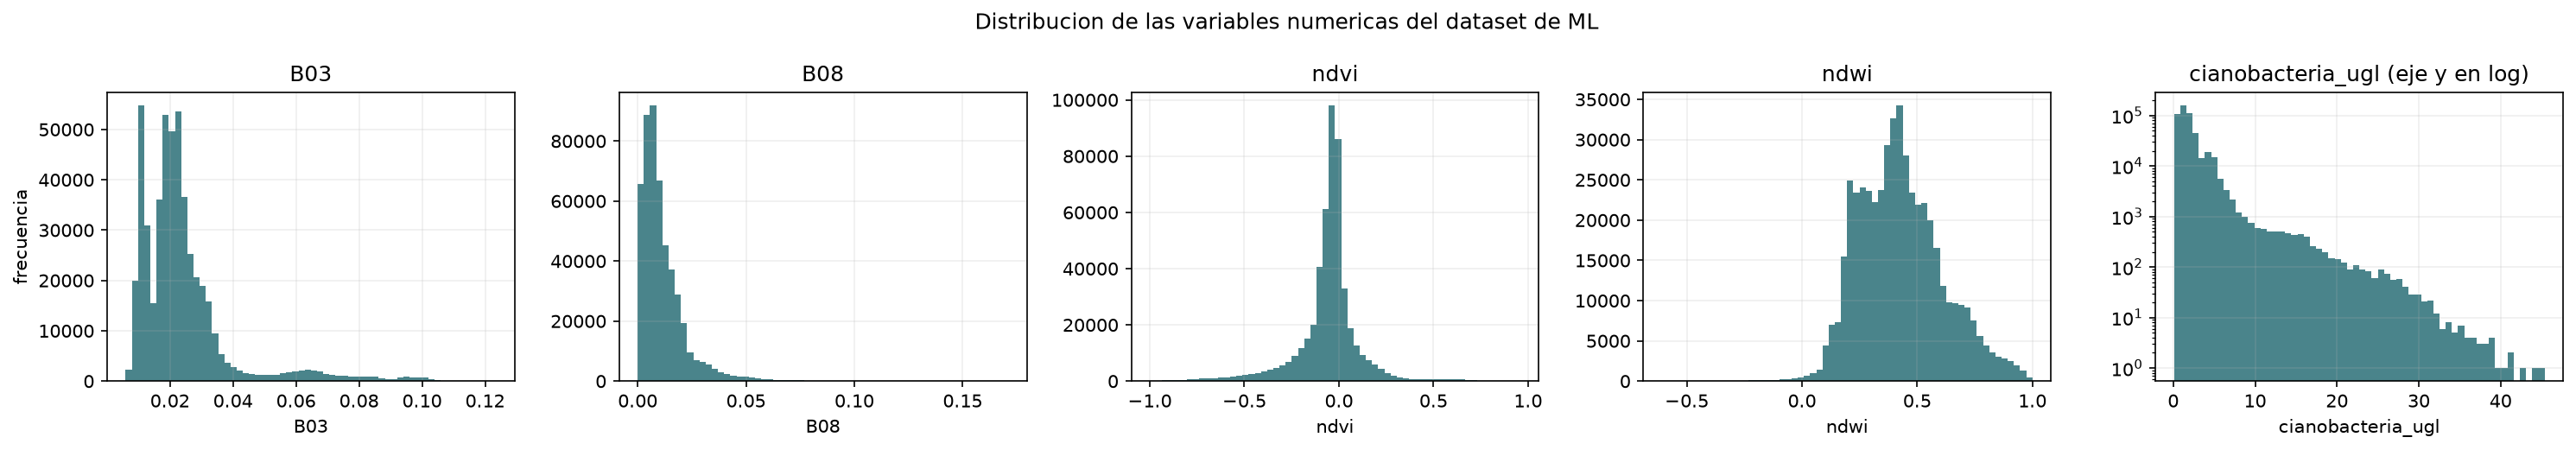

In [4]:
ruta = eda.figura_histogramas(tabla)
from IPython.display import Image
display(Image(filename=str(ruta)))


**Lectura:** `B03` y `B08` se concentran en valores bajos de reflectancia
(agua), con colas cortas. `ndvi` esta centrado cerca de 0 con una cola
hacia valores negativos, coherente con agua abierta. `ndwi` se concentra en
valores positivos altos, tambien coherente con agua. `cianobacteria_ugl`
muestra la asimetria esperada: la mayoria de celdas por debajo de 2-3
µg/L y una cola larga hacia valores mas altos, que es justamente la zona
que interesa detectar.

### 1.3 Boxplots de cianobacteria por lago y por fecha

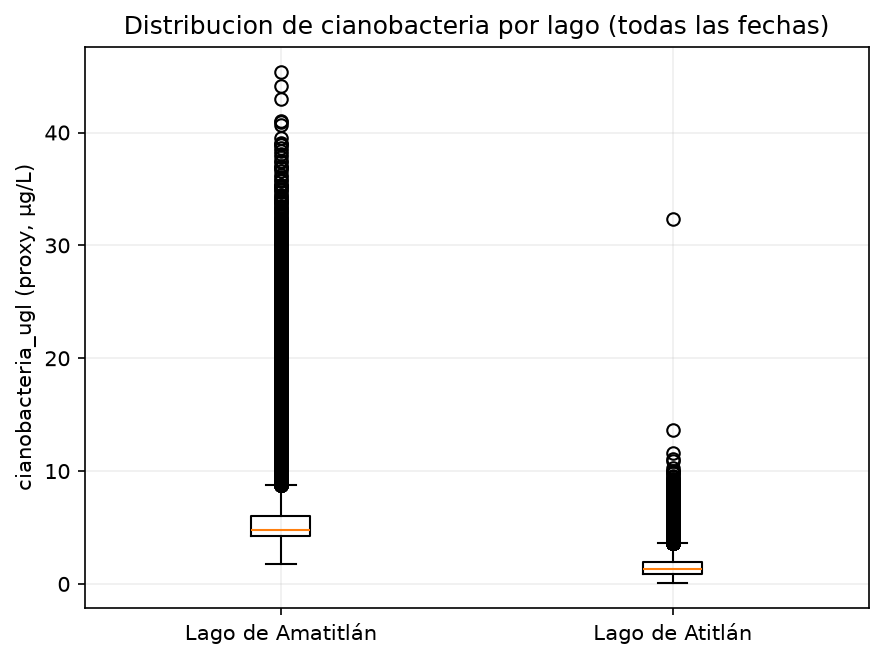

In [5]:
ruta = eda.figura_boxplot_cianobacteria_por_lago(tabla)
display(Image(filename=str(ruta)))


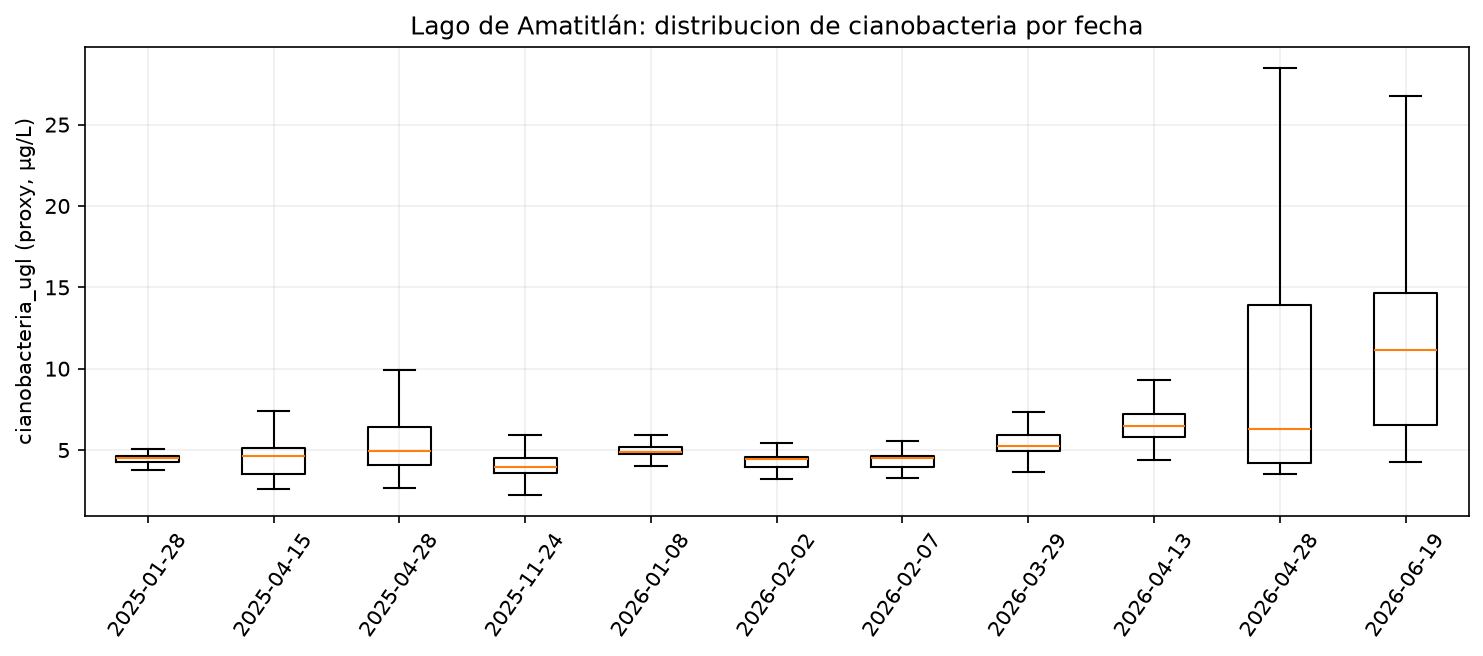

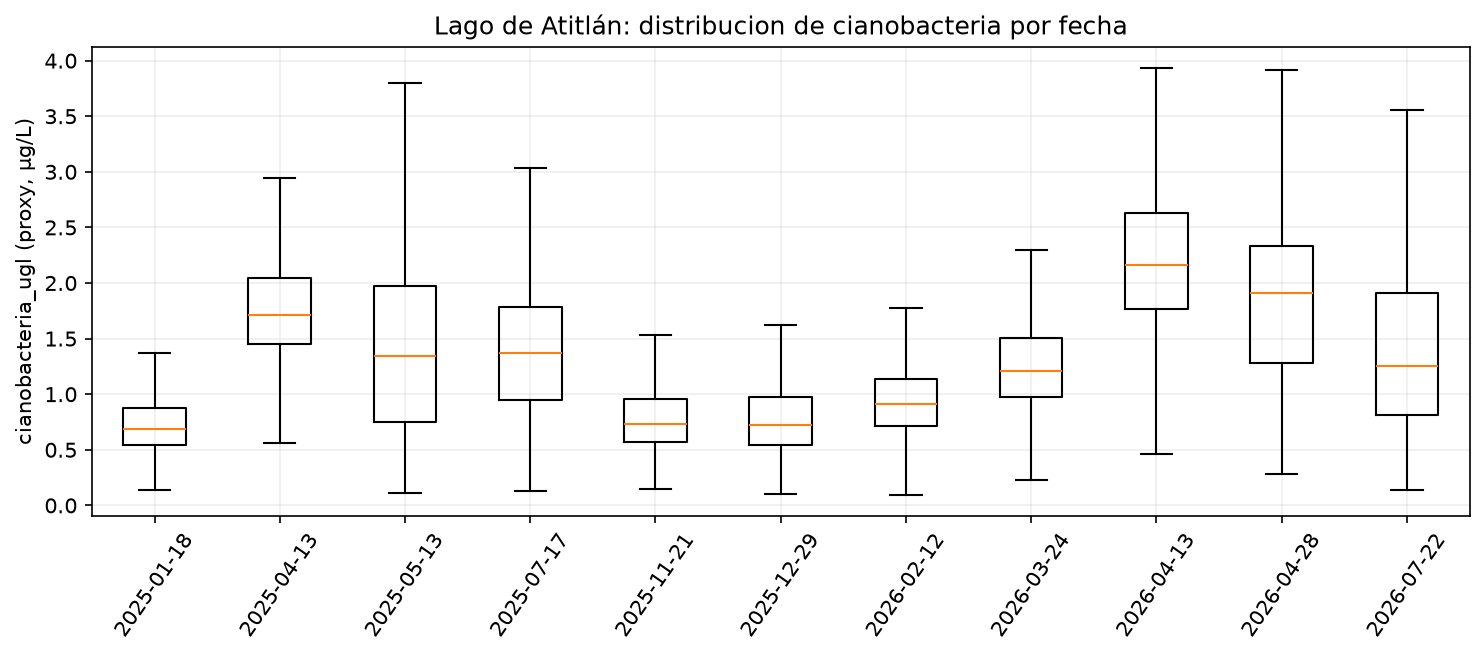

In [6]:
for lago in sorted(LAGOS):
    ruta = eda.figura_boxplot_cianobacteria_por_fecha(tabla, lago)
    display(Image(filename=str(ruta)))


**Lectura:** el boxplot por lago ya deja ver, antes de calcular ningun
umbral, que Amatitlan tiene una mediana y una dispersion mucho mayores que
Atitlan, con varios valores atipicos altos. Por fecha, Amatitlan muestra
una mediana creciente hacia las ultimas fechas (abril y junio de 2026),
consistente con lo que ya se habia observado en la Parte 1. Atitlan se
mantiene comprimido en valores bajos en las 11 fechas.

### 1.4 Matriz de correlacion

,B03,B08,ndvi,ndwi,cianobacteria_ugl
B03,1.000,0.883,-0.025,-0.481,0.658
B08,0.883,1.000,0.174,-0.703,0.700
ndvi,-0.025,0.174,1.000,-0.347,0.011
ndwi,-0.481,-0.703,-0.347,1.000,-0.345
cianobacteria_ugl,0.658,0.700,0.011,-0.345,1.000


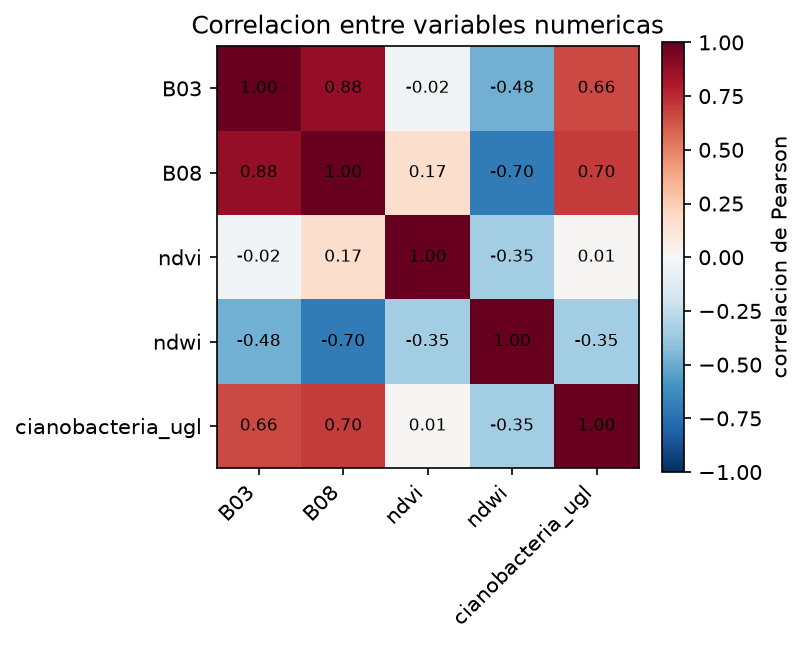

In [7]:
corr = eda.matriz_correlacion(tabla)
display(corr.round(3))
ruta = eda.figura_matriz_correlacion(tabla)
display(Image(filename=str(ruta)))


**Lectura:** `B03` (0.66) y `B08` (0.70) correlacionan positivamente con
`cianobacteria_ugl`, lo cual es una buena senal de que, aun sin poder usar
`B04` ni `ndvi`, quedan predictores con relacion real a la respuesta.
`ndwi` correlaciona negativo (-0.35): a mayor cianobacteria, el agua se ve
"menos limpia" para ese indice. `ndvi` practicamente no correlaciona
(0.01) con `cianobacteria_ugl` en este dataset agregado a 50 m, aunque de
todas formas queda excluido como predictor por fuga indirecta a traves de
`B04` (ver seccion 5), no por esta correlacion baja.

### 1.5 Dispersion geografica

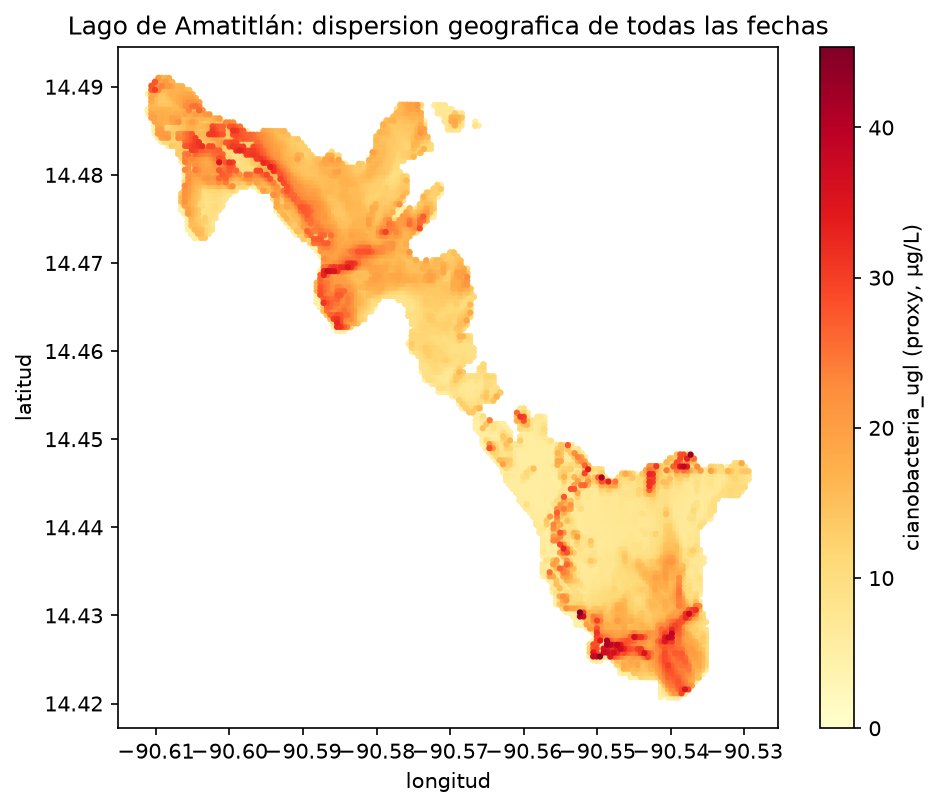

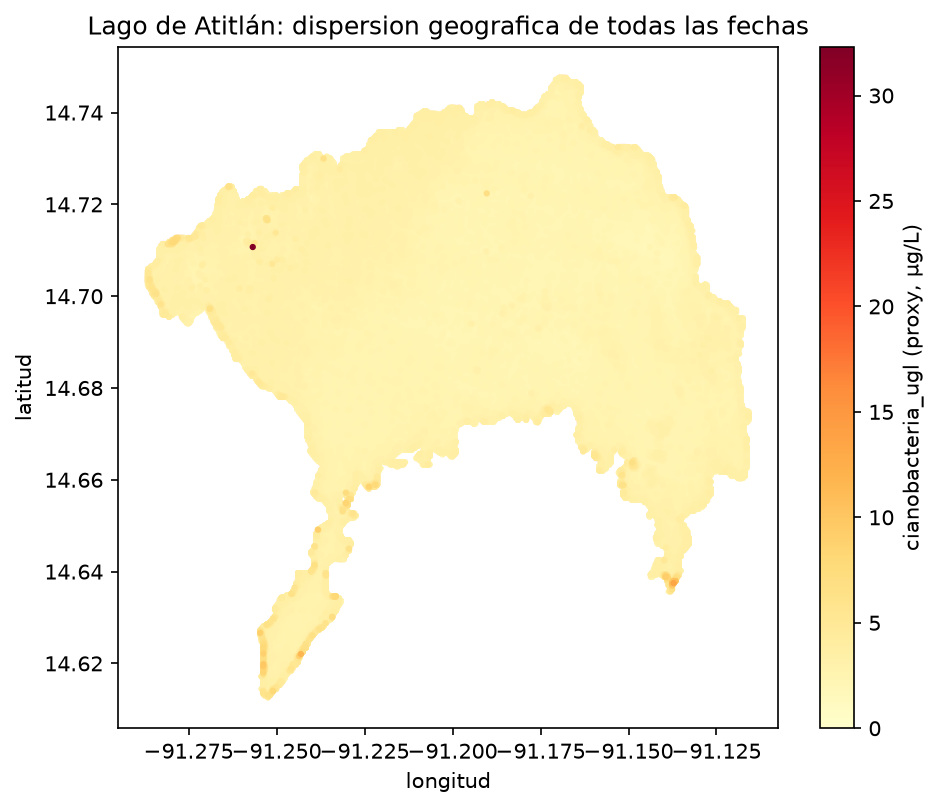

In [8]:
for lago in sorted(LAGOS):
    ruta = eda.figura_dispersion_geografica(tabla, lago)
    display(Image(filename=str(ruta)))


**Lectura:** en Amatitlan se ven zonas con tonos mas intensos repartidas
por buena parte del lago (coherente con el 8.1/8.2 de la Parte I, donde se
identifico un evento reciente y extenso). En Atitlan casi todos los puntos
quedan en el extremo bajo de la escala de color, con apenas unos pocos
puntos mas intensos.

## 2. Ejercicio 2 - Variable respuesta

### 2.1 Binarizacion

`cyano_alta = 1` si `cianobacteria_ugl >= UMBRAL_CIANOBACTERIA_ALTO_UGL`,
si no `0`. El umbral (10.0 µg/L) es el mismo que ya fijo y justifico la
Parte I para los ejercicios 8.1/8.2, antes de ver estos resultados; se
reutiliza tal cual para que ambas partes del laboratorio sean coherentes
entre si.

In [9]:
from src.respuesta import (
    binarizar,
    construir_respuesta,
    distribucion_respuesta,
    escribir_distribucion,
    figura_barras_apiladas_por_fecha,
    resumen_desbalance,
    verificar_respuesta,
)

tabla_resp = binarizar(tabla)
print(f"Umbral usado: {UMBRAL_CIANOBACTERIA_ALTO_UGL} µg/L")
display(tabla_resp[['lago', 'fecha', 'cianobacteria_ugl', 'cyano_alta']].sample(5, random_state=0))


Umbral usado: 10.0 µg/L


,lago,fecha,cianobacteria_ugl,cyano_alta
112312,atitlan,2025-04-13,1.938321,0
206253,atitlan,2025-07-17,1.412650,0
464133,atitlan,2026-07-22,0.836040,0
467881,atitlan,2026-07-22,3.787006,0
121054,atitlan,2025-05-13,2.639147,0


### 2.2 Justificacion bibliografica del punto de corte

**OECD (1982), clasificacion trofica de lagos por clorofila-a media
anual.** La OECD define, entre otros indicadores, rangos de clorofila-a
(mg/m³, equivalente a µg/L) para clasificar el estado trofico de un lago:
oligotrofico hasta 2.5, mesotrofico 2.5-8, **eutrofico 8-25** e
hipereutrofico desde 25. El umbral de 10 µg/L usado aqui cae dentro del
rango eutrofico, es decir, en la zona donde la literatura limnologica
considera que un lago ya muestra signos de exceso de nutrientes asociado a
mayor riesgo de floraciones.

**Organizacion Mundial de la Salud (2003), *Guidelines for safe
recreational water environments*, Volumen 1.** La OMS define un marco de
niveles de alerta para cianobacterias en agua recreativa basado en
clorofila-a con dominancia de cianobacterias: el nivel de vigilancia va
aproximadamente de 1 a 12 µg/L, y el siguiente nivel (Alerta 1, que ya
implica un riesgo de salud publica mayor) comienza alrededor de 12 µg/L.
El umbral de 10 µg/L usado en este laboratorio cae en el extremo superior
del nivel de vigilancia de la OMS, es decir, justo antes de entrar a la
zona de alerta. Se elige documentar esto con precision, sin llamarlo
"Alerta 1" (una imprecision que aparecia en un comentario de codigo de la
Parte I y que se corrige aqui), porque el objetivo es que el punto de
corte tenga respaldo cientifico exacto, no solo una etiqueta.

En conjunto, ambas fuentes ubican 10 µg/L en la frontera entre "todavia
vigilancia" y "ya eutrofico / a punto de alerta", que es exactamente el
tipo de punto de corte que conviene para separar observaciones de baja
presencia de observaciones de alta presencia sin ser ni demasiado laxo ni
demasiado estricto.

**Referencias**

- Organisation for Economic Co-operation and Development. (1982). *Eutrophication of waters: Monitoring, assessment and control*. OECD.
- World Health Organization. (2003). *Guidelines for safe recreational water environments: Volume 1, Coastal and fresh waters*. https://www.who.int/publications/i/item/9241545801

### 2.3 Distribucion de la respuesta: global, por lago y por fecha

In [10]:
filas_dist = distribucion_respuesta(tabla_resp)
escribir_distribucion(filas_dist)
df_dist = pd.DataFrame(filas_dist)

print('--- Global ---')
display(df_dist[df_dist['corte'] == 'global'])
print('--- Por lago ---')
display(df_dist[df_dist['corte'] == 'por_lago'])


--- Global ---


,corte,lago,fecha,cyano_alta,n,pct
0,global,,,0,486312,98.7081
1,global,,,1,6365,1.2919


--- Por lago ---


,corte,lago,fecha,cyano_alta,n,pct
2,por_lago,amatitlan,,0,54284,89.5155
3,por_lago,amatitlan,,1,6358,10.4845
4,por_lago,atitlan,,0,432028,99.9984
5,por_lago,atitlan,,1,7,0.0016


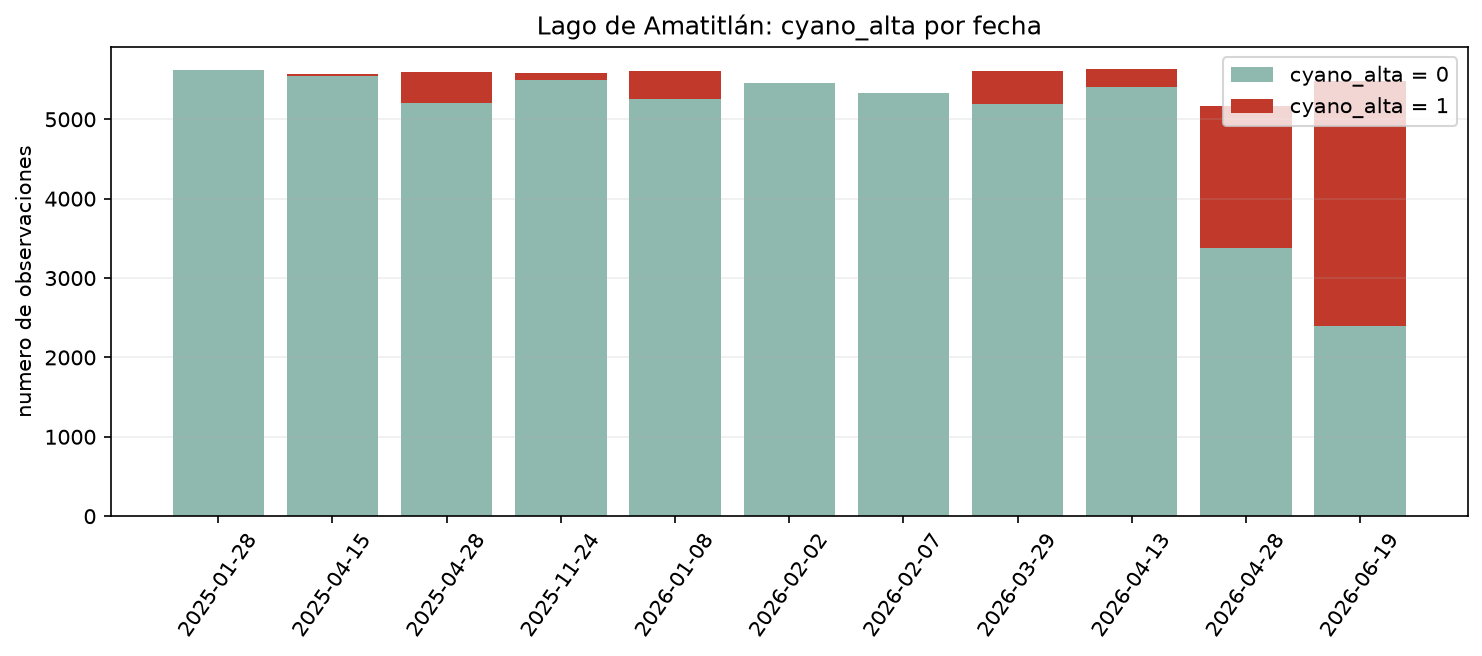

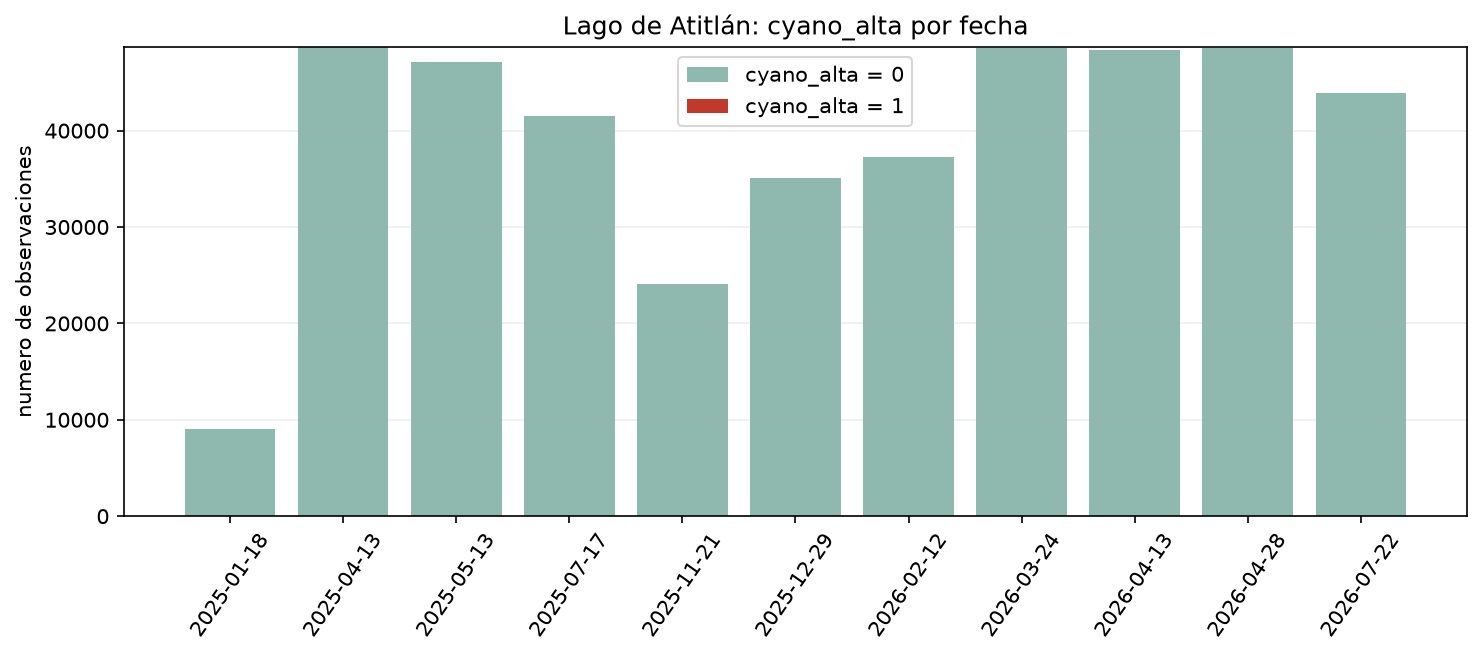

In [11]:
for lago in sorted(LAGOS):
    ruta = figura_barras_apiladas_por_fecha(tabla_resp, lago)
    display(Image(filename=str(ruta)))


**Lectura:** casi todas las barras rojas (`cyano_alta = 1`) del dataset
completo pertenecen a Amatitlan. Las barras de Atitlan son, en la
practica, monocromaticas: 0 o casi 0 observaciones positivas en cada
fecha. Esto ya anticipa el desbalance que se cuantifica en la siguiente
seccion.

### 2.4 Desbalance de clases

Se cuantifica el desbalance real (no se asume) antes de discutir sus
consecuencias.

In [12]:
resumen = resumen_desbalance(tabla_resp)
display(pd.DataFrame(resumen).T)


,n_total,n_positivos,n_negativos,pct_positivos,ratio_negativos_por_positivo
global,492677.0,6365.0,486312.0,1.2919,76.40
amatitlan,60642.0,6358.0,54284.0,10.4845,8.54
atitlan,432035.0,7.0,432028.0,0.0016,61718.29


**Lo que muestran los numeros:** globalmente solo el 1.29 % de las
observaciones son `cyano_alta = 1` (6,365 de 492,677), una razon de
aproximadamente 76 negativos por cada positivo. El desbalance no es
parejo entre lagos: en Amatitlan el 10.48 % de las observaciones son
positivas (razon ~8.5:1, fuerte pero manejable), mientras que en Atitlan
apenas 7 de 432,035 observaciones son positivas (0.0016 %, razon de mas de
61,000:1). En la practica, **el 99.9 % de todas las observaciones
positivas del dataset completo vienen de Amatitlan**.

**Consecuencias para el entrenamiento y la evaluacion:**

- **Accuracy enganosa.** Un modelo que prediga siempre 0 (nunca alta
  presencia) tendria 98.7 % de accuracy global sin haber aprendido nada
  util. Accuracy sola no sirve para elegir ni evaluar el modelo.
- **Sesgo hacia la clase mayoritaria.** Sin ajustes (pesos de clase,
  remuestreo, etc.), los tres algoritmos pedidos (Regresion Logistica,
  Random Forest, Gradient Boosting/XGBoost) tienden a minimizar el error
  total prediciendo casi siempre la clase negativa, que es la mas
  representada.
- **Por eso hay que mirar Precision, Recall, F1 y ROC-AUC** en vez de
  accuracy: estas metricas si distinguen si el modelo esta detectando la
  clase positiva (rara mas util) o simplemente ignorandola.
- **Generalizacion entre lagos en riesgo.** Con solo 7 observaciones
  positivas en todo Atitlan, un modelo entrenado unicamente con datos de
  Atitlan practicamente no tendria con que aprender el patron de "alta
  presencia": el ejercicio 7 (generalizacion entre lagos) de la siguiente
  entrega debe anticipar que el experimento "entrenar en Atitlan, evaluar
  en Amatitlan" sera particularmente dificil por esta escasez casi total
  de positivos del lado de Atitlan, no solo por diferencias ambientales
  entre los lagos.

### 2.5 Variables que no pueden usarse como predictoras (fuga)

El indice de cianobacteria del que sale la respuesta se calcula con el
script CyanoLakes:

```
NDCI = (B05 - B04) / (B05 + B04)
chl  = 826.57*NDCI^3 - 176.43*NDCI^2 + 19*NDCI + 4.071
```

`B05` no se descargo en la Parte I, asi que la fuga entra unicamente por
`B04`. Quedan excluidas como predictoras `cianobacteria_ugl` (es
literalmente la respuesta), `B04` (entra directo en el NDCI) y `ndvi`
(usa B04 en su formula, fuga indirecta). Un matiz que vale la pena
documentar: `B03` y `B08` si pueden usarse, porque solo intervienen en la
mascara de agua propia del script (que decide donde es agua, no cuanto
vale la clorofila), no en el valor numerico de `chl`.

In [13]:
display(pd.Series(VARIABLES_EXCLUIDAS_RESPUESTA, name='razon').to_frame())


,razon
cianobacteria_ugl,es la variable de la que se deriva cyano_alta
B04,entra directamente en el NDCI que calcula la c...
ndvi,"se calcula como (B08-B04)/(B08+B04): usa B04, ..."


## 3. Verificacion final (gate para el ejercicio 3)

In [14]:
resumen_gate = verificar_respuesta(tabla_resp, filas_distribucion=filas_dist)
print(f"Verificacion correcta: {resumen_gate['observaciones']} observaciones, "
      f"{resumen_gate['positivos']} con cyano_alta=1.")


Verificacion correcta: 492677 observaciones, 6365 con cyano_alta=1.
